

## 📱 Deux opérateurs de mobile money au Tchad


---

### Le contexte

Un agent de mobile money travaille avec **deux comptes** : un compte **Moov Money** et un
compte **Airtel Money**. Chaque opération lui envoie un SMS de confirmation : un dépôt, un
retrait, un transfert, une commission, un solde. Pendant dix mois, tous ces SMS se sont
accumulés dans son téléphone. Il les a exportés.

Personne n'a jamais rangé ce fichier. Les montants sont noyés dans du texte, les deux
opérateurs n'écrivent pas les nombres de la même façon, la moitié des colonnes ne servent
à rien, et les dates sont stockées en millisecondes depuis 1970.

**Votre mission :** transformer ces deux exports bruts en une analyse chiffrée de l'activité
de cet agent, et répondre à la question qu'il vous pose :

> « Lequel de mes deux comptes travaille le plus, et à quel moment ? »

C'est exactement le métier : on ne vous donnera jamais un tableau propre.

---



## Question 1 — Nettoyer le texte d'un SMS *(1 pt)*

Voici un vrai SMS Moov Money. Il tient sur quatre lignes, avec des espaces en trop
et des `\n` (retours à la ligne) au milieu.

Écrivez une fonction `nettoyer(msg)` qui rend le message sur **une seule ligne**, sans
espaces doubles et sans espace au début ni à la fin.

In [ ]:
message = ("Vous avez credite OUSMANE RATOU (23593013249) de 1.000,00 FCFA Le 13-11-2025 19:43:02.\n"
           "Commission: 33,09 FCFA\nVotre solde est de 12.922,63 FCFA. \nRef: CKD91NPATV.")


# 1. Definir la fonction nettoyer(msg) qui :
def nettoyer(msg):
  #    - remplace les retours a la ligne "\n" par une espace
  msg = msg.replace('\n', ' ')
  #    - supprime les espaces en double (indice : .split() puis " ".join())
  msg = " ".join(msg.split())
  #    - supprime les espaces au debut et a la fin
  msg = msg.strip()
  #    - renvoie le resultat
  return msg

# 2. Afficher la longueur du message avant nettoyage, puis apres
print("Longueur du message avant nettoyage :", len(message))
message_nettoye = nettoyer(message)
print( "Longueur du message aprés nettoyage :", len(message_nettoye))

# 3. Afficher le message nettoye
print("\nMessage nettoyé :")
print(message_nettoye)

# 4. Afficher combien de fois le mot "FCFA" apparait dans le message
print("Le mot 'FCFA' apparait", message_nettoye.count("FCFA"), "fois")

Longueur du message avant nettoyage : 162
Longueur du message aprés nettoyage : 161

Message nettoyé :
Vous avez credite OUSMANE RATOU (23593013249) de 1.000,00 FCFA Le 13-11-2025 19:43:02. Commission: 33,09 FCFA Votre solde est de 12.922,63 FCFA. Ref: CKD91NPATV.
Le mot 'FCFA' apparait 3 fois


## Question 2 — Convertir un montant en nombre *(1 pt)*

Les deux opérateurs n'écrivent pas les nombres de la même façon. C'est le premier vrai
piège du jeu de données :

| Opérateur | Écriture | Sens |
|---|---|---|
| Moov Money | `11.000,00` | le `.` sépare les milliers, la `,` sépare les décimales |
| Airtel Money | `40000.00` | le `.` sépare les décimales, pas de séparateur de milliers |

`float("11.000,00")` plante. Écrivez `montant_en_nombre(texte)` qui gère **les deux cas**
et renvoie un `float`.

In [ ]:
# 1. Definir montant_en_nombre(texte) :
def montant_en_nombre(texte):

  #    - enlever les espaces autour, et un eventuel point ou virgule final
  texte = texte.strip().rstrip(",.")
  #    - S'IL Y A UNE VIRGULE : c'est le format Moov.
  if ',' in texte:

    #         supprimer tous les points, puis remplacer la virgule par un point
    texte = texte.replace('.', '')
    texte = texte.replace(',', '.')
  #    - SINON : c'est deja le format que float() comprend
  #    - renvoyer float(...)
  return float(texte)


# 2. Tester la fonction sur cette liste avec une boucle for,
#    en affichant "texte -> nombre" pour chaque element
tests = ["11.000,00", "40000.00", "33,09", "500", "1.332,80", "1.200.000,00"]
for t in tests:
  print(t, "->", montant_en_nombre(t))

11.000,00 -> 11000.0
40000.00 -> 40000.0
33,09 -> 33.09
500 -> 500.0
1.332,80 -> 1332.8
1.200.000,00 -> 1200000.0


## Question 3 — Extraire le montant d'un SMS *(1 pt)*

Maintenant on cherche le montant **à l'intérieur du texte**. Regardez la règle :
dans tous ces messages, le premier montant est **le nombre qui précède le premier `FCFA`**.

```
Vous avez credite ... de 1.000,00 FCFA Le 13-11-2025 ...   ->  1000.0
TID:CI251203.1652 Vous avez envoye 2500.00 FCFA a ...      ->  2500.0
Vous avez recu une commission de 124,10 FCFA. ...          ->  124.1
Votre transaction est en cours.                            ->  None
```

Écrivez `extraire_montant(body)` avec le module `re`. **Attention :** certains SMS ne
contiennent aucun montant. La fonction doit renvoyer `None`, pas planter.

In [ ]:
import re

# 1. Compiler une expression reguliere qui capture le nombre colle a FCFA.
#    Le nombre = un chiffre, puis des chiffres/points/virgules : (\d[\d.,]*)
#    Puis d'eventuelles espaces, puis le mot FCFA
MOTIF_MONTANT = re.compile(r'(\d[\d.,]*)\s+FCFA')

# 2. Definir extraire_montant(body) :
def extraire_montant(body):

  body = str(body)

  #    - chercher le motif dans str(body)  (str() car pandas peut donner autre chose)
  match = MOTIF_MONTANT.search(body)
  #    - si on ne trouve rien : renvoyer None
  if not match :
    return None

  #    - sinon : passer le groupe capture a montant_en_nombre()
  texte_montant = match.group(1)
  #      et proteger l'appel avec try / except ValueError -> renvoyer None
  try:
    return montant_en_nombre(texte_montant)
  except ValueError:
    return None

# 3. Tester sur ces quatre messages
exemples = [
    message,
    "TID:CI251203.1652.A15229 Vous avez envoye 2500.00 FCFA a Zara Tolli,66****45. Le solde de votre compte est  12210.37 FCFA",
    "Vous avez recu une commission de 124,10 FCFA. Transaction de l'agent 93463346 - Ramatou Adjid.",
    "Votre transaction est en cours.",
]
for exemple in exemples:
  print(extraire_montant(exemple))

1000.0
2500.0
124.1
None


## Question 4 — Reconnaître le type d'un SMS *(1 pt)*

Tous ces SMS ne racontent pas la même chose. Voici les sept familles, avec le repère
qui permet de les distinguer :

| Catégorie | Comment la reconnaître |
|---|---|
| `commission` | contient `commission de` |
| `depot` | **commence par** `Vous avez credite` (l'agent a crédité un client) |
| `retrait` | **commence par** `Retrait reussi` |
| `envoi` | contient `Vous avez envoye`, ou commence par `Transfert confirme` |
| `echec` | contient `echoue` |
| `reception` | contient `recu` |
| `solde` | contient `solde` |
| `autre` | rien de tout ça |

⚠️ **L'ordre des tests compte.** « Vous avez recu une commission de 124,10 FCFA »
contient `recu` **et** `commission de`. Testez `commission` en premier.

Écrivez `categorie_message(body)`.

In [ ]:
# 1. Definir categorie_message(body) :
def categorie_message(body):

   #    - mettre le texte en minuscules dans une variable t  (indice : str(body).lower()
   t = str(body).lower()
   #      -- et penser a mettre les repere du tableau en minuscules aussi !)
   #    - enchainer les if / return dans l'ordre du tableau ci-dessus
   if "commission de" in t:
     return "commission"
   elif t.startswith("vous avez credite"):
     return "depot"
   elif t.startswith("retrait reussi"):
     return "retrait"
   elif "vous avez envoye" in t or t.startswith("transfert confirme"):
     return "envoi"
   elif "echoue" in t:
     return "echec"
   elif "recu" in t:
     return "reception"
   elif "solde" in t:
     return "solde"
   else:
     return "autre"

   #    - le dernier cas renvoie "autre"


# 2. Tester la fonction sur la liste messages ci-dessous en affichant
#    la categorie devant les 55 premiers caracteres de chaque message
messages = [
    "Vous avez credite OUSMANE RATOU (23593013249) de 1.000,00 FCFA Le 13-11-2025 19:43:02.",
    "Retrait reussi. Donnez 52.500,00 FCFA  au client Zara Tolli (23599422609) le 18-10-2025 13:29:52.",
    "Vous avez recu une commission de 124,10 FCFA. Transaction de l'agent 93463346 - Ramatou Adjid.",
    "TID:CI251203.1652.A15229 Vous avez envoye 2500.00 FCFA a Zara Tolli,66****45.",
    "TID: PP260524.1649.A41262. Vous avez recu 30000.00 FCFA de  Djibrine Saboun,63272742.",
    "TID : PP251111.1443.A49642,Cher client votre transaction a echoue car votre beneficiaire est indisponible.",
    "Votre solde Moov Money est de: 2.905,63 FCFA.",
    "Initiator is invalid",
]
for m in messages:
  cat = categorie_message(m)
  print(cat, "/", m[:55])

depot / Vous avez credite OUSMANE RATOU (23593013249) de 1.000,
retrait / Retrait reussi. Donnez 52.500,00 FCFA  au client Zara T
commission / Vous avez recu une commission de 124,10 FCFA. Transacti
envoi / TID:CI251203.1652.A15229 Vous avez envoye 2500.00 FCFA 
reception / TID: PP260524.1649.A41262. Vous avez recu 30000.00 FCFA
echec / TID : PP251111.1443.A49642,Cher client votre transactio
solde / Votre solde Moov Money est de: 2.905,63 FCFA.
autre / Initiator is invalid


## Question 5 — Compter les catégories avec une boucle *(1 pt)*

Écrivez `compter_categories(liste_de_messages)` qui parcourt une liste de SMS et renvoie
un **dictionnaire** `{catégorie: nombre}`, **trié du plus fréquent au moins fréquent**.

Interdit d'utiliser `collections.Counter` : c'est une question sur la boucle et le
dictionnaire.

In [ ]:
# 1. Definir compter_categories(liste) :
def compter_categories(liste_de_message):
   #    - creer un dictionnaire vide compte = {}
   compte = {}
   #    - pour chaque message : trouver sa categorie avec categorie_message()
   #      puis ajouter 1 au compteur  (indice : compte.get(cle, 0) + 1)
   for m in liste_de_message:
     cat = categorie_message(m)
     compte[cat] = compte.get(cat, 0) + 1

   #    - trier le dictionnaire par valeur decroissante avant de le renvoyer
   #      (indice : sorted(compte.items(), key=..., reverse=True) puis dict(...))
   compte_trie = sorted(compte.items(), key=lambda x: x[1], reverse=True)
   return dict(compte_trie)

# 2. Appliquer la fonction a la liste messages de la question 4 et afficher le resultat
resultat = compter_categories(messages)
print( "Dictionnaire trié :", resultat)

# 3. Afficher la categorie la plus frequente et son nombre, en une phrase
cat_plus_frequente = list(resultat.keys())[0]
nb = resultat[cat_plus_frequente]
print(f"La categorie la plus frequente est : {cat_plus_frequente} avec {nb} message(s).")

Dictionnaire trié : {'depot': 1, 'retrait': 1, 'commission': 1, 'envoi': 1, 'reception': 1, 'echec': 1, 'solde': 1, 'autre': 1}
La categorie la plus frequente est : depot avec 1 message(s).


## Question 6 — Tout mettre dans une fiche *(1 pt)*

Dernière question de la partie A : rassemblez votre travail. Écrivez `infos_message(body)`
qui renvoie un **dictionnaire** à quatre clés :

```python
{"categorie": "depot", "montant": 1000.0, "solde": 12922.63, "reference": "CKD91NPATV"}
```

- `categorie` et `montant` : vos fonctions des questions 3 et 4.
- `solde` : le nombre qui suit le mot `solde` dans le message (`None` s'il n'y en a pas).
- `reference` : le code qui suit `Ref:`, `TID:`, `Trans.ID:` ou `ID Trans:` (`None` sinon).
  Deux formes existent : `CKD91NPATV` (Moov) et `PP260524.1649.A41262` (Airtel).

In [ ]:
# 1. Ecrire deux expressions regulieres :
#    MOTIF_SOLDE : le mot "solde", puis n'importe quoi qui n'est pas un chiffre,
#                  puis le nombre, puis FCFA.  Ajouter re.IGNORECASE.
#    MOTIF_REF   : Ref / TID / Trans.ID / ID Trans, un ':' optionnel, des espaces
#                  optionnelles, puis le code. Deux formes possibles, separees par |  :
#                    [A-Z]{2}\d{6}\.\d{4}\.[AB]\d+     -> PP260524.1649.A41262
#                    [A-Z0-9]{8,}                       -> CKD91NPATV
MOTIF_SOLDE = re.compile(r'solde[^0-9]+([0-9.,]+)\s+FCFA', re.IGNORECASE)
MOTIF_REF = re.compile(r'(Ref|TID|Trans\.ID|ID Trans):\s*([A-Z]{2}\d{6}\.\d{4}\.[AB]\d+|[A-Z0-9]{8,})', re.IGNORECASE)

# 2. Definir infos_message(body) qui renvoie le dictionnaire a 4 cles.
def infos_message(body):
  categorie = categorie_message(body)
  montant = extraire_montant(body)

  #    Pour solde et reference : chercher, et si on ne trouve rien mettre None.
  match_solde = MOTIF_SOLDE.search(body)
  if match_solde:
    solde = montant_en_nombre(match_solde.group(1))
  else:
    solde = None


  match_ref = MOTIF_REF.search(body)
  if match_ref:
    reference = match_ref.group(2)
  else:
    reference = None

  return {
      "categorie": categorie,
      "montant": montant,
      "solde": solde,
      "reference": reference
  }

# 3. Tester sur message (Moov) et sur le message Airtel ci-dessous,
#    en affichant un dictionnaire par ligne
airtel_exemple = "TID: PP260524.1649.A41262. Vous avez recu 30000.00 FCFA de  Djibrine Saboun,63272742. Votre solde est 69074.21 FCFA"
print("Test Moov :", infos_message(message))
print("Test Airtel :", infos_message(airtel_exemple))


Test Moov : {'categorie': 'depot', 'montant': 1000.0, 'solde': 12922.63, 'reference': 'CKD91NPATV'}
Test Airtel : {'categorie': 'reception', 'montant': 30000.0, 'solde': 69074.21, 'reference': 'PP260524.1649.A41262'}


---
# Partie B — Charger et interroger avec NumPy & Pandas
**Module 2 · Questions 7 à 11 · 5 points**

Fini le Python à la main : à partir d'ici, les 29 386 SMS tiennent dans un seul tableau,
et vos six fonctions vont s'appliquer dessus d'un coup.

## Question 7 — Charger les deux fichiers et les empiler *(1 pt)*

Chargez les deux CSV, ajoutez à chacun une colonne qui dit d'où il vient, puis
**empilez-les** en un seul DataFrame `sms`.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# 1. Importer pandas (pd), numpy (np), matplotlib.pyplot (plt), seaborn (sns)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
#    et activer le theme seaborn
sns.set_theme()

# 2. Lire les deux fichiers dans moov et airtel
#    (sur Colab : "/content/drive/MyDrive/dataset/sms_moov_money.csv")
moov = pd.read_csv("/content/drive/MyDrive/mobile_money/sms_moov_money.csv")
airtel = pd.read_csv("/content/drive/MyDrive/mobile_money/sms_airtel_money.csv")

#

# 3. Ajouter a moov une colonne "operateur" qui vaut "Moov Money"
moov["operateur"] = "Moov Money"
#    Ajouter a airtel une colonne "operateur" qui vaut "Airtel Money"
airtel["operateur"] = "Airtel Money"

# 4. Empiler les deux tableaux dans sms avec pd.concat(...)
#    ATTENTION : ignore_index=True, sinon les numeros de ligne se repetent
sms = pd.concat([moov, airtel], ignore_index=True)
# 5. Afficher : la forme de chaque tableau, la forme du total,
print("Forme de Moov :", moov.shape)
print("Forme de Airtel :", airtel.shape)
print("Forme du tableau Total sms :", sms.shape)
#    puis sms.head(3), puis sms.info()
sms.head(3)

Forme de Moov : (5876, 17)
Forme de Airtel : (23510, 17)
Forme du tableau Total sms : (29386, 17)


,protocol,address,date,type,subject,body,toa,sc_toa,service_center,read,status,locked,date_sent,sub_id,readable_date,contact_name,operateur
0,0,MoovMoney,1760730074142,1,NaN,Vous avez credite DANA NASSOUR (23530619288) d...,NaN,NaN,0,1,-1,0,1760730073000,1,17 oct. 2025 20:41:14,(Unknown),Moov Money
1,0,MoovMoney,1760762967165,1,NaN,Le numero 23594346715 vous a achete le forfait...,NaN,NaN,0,1,-1,0,1760762965000,1,18 oct. 2025 05:49:27,(Unknown),Moov Money
2,0,MoovMoney,1760765513784,1,NaN,Vous avez credite SALEH NGARLEMDANA (235948962...,NaN,NaN,0,1,-1,0,1760765512000,1,18 oct. 2025 06:31:53,(Unknown),Moov Money


In [ ]:
sms.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29386 entries, 0 to 29385
Data columns (total 17 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   protocol        29386 non-null  int64  
 1   address         29386 non-null  object 
 2   date            29386 non-null  int64  
 3   type            29386 non-null  int64  
 4   subject         0 non-null      float64
 5   body            29386 non-null  object 
 6   toa             0 non-null      float64
 7   sc_toa          0 non-null      float64
 8   service_center  29386 non-null  int64  
 9   read            29386 non-null  int64  
 10  status          29386 non-null  int64  
 11  locked          29386 non-null  int64  
 12  date_sent       29386 non-null  int64  
 13  sub_id          29386 non-null  int64  
 14  readable_date   29386 non-null  object 
 15  contact_name    29386 non-null  object 
 16  operateur       29386 non-null  object 
dtypes: float64(3), int64(9), object

## Question 8 — NumPy sur les commissions Airtel *(1 pt)*

Sur les 23 510 SMS Airtel, 17 200 sont des avis de commission. Sortez tous ces montants
dans un **tableau NumPy** et décrivez-les.

In [ ]:
# 1. Construire un masque : lignes ou operateur vaut "Airtel Money"
#    ET ou body contient "commission de"   (indice : .str.contains(..., case=False))
masque = (sms["operateur"] == "Airtel Money") & (sms["body"].str.contains("commission de", case=False))

# 2. Recuperer la colonne body de ces lignes, appliquer extraire_montant a chacune,
#    et mettre le resultat dans un tableau numpy :  np.array([...], dtype=float)
tableau_commissions = np.array(sms[masque]["body"].apply(extraire_montant), dtype=float)

# 3. Retirer les valeurs manquantes du tableau : tableau[~np.isnan(tableau)]
tableau_commissions = tableau_commissions[~np.isnan(tableau_commissions)]

# 4. Afficher, avec numpy et arrondi a 2 decimales :
#    la taille, la moyenne, la mediane, l'ecart-type, le minimum, le maximum,
#    le 90e percentile (np.percentile) et la somme totale
print(f"Taille : {tableau_commissions.size}")
print(f"Moyenne : {np.round(np.mean(tableau_commissions), 2)}")
print(f"Mediane : {np.round(np.median(tableau_commissions), 2)}")
print(f"Ecart-type : {np.round(np.std(tableau_commissions), 2)}")
print(f"Minimum : {np.round(np.min(tableau_commissions), 2)}")
print(f"Maximum : {np.round(np.max(tableau_commissions), 2)}")
print(f"90e percentile : {np.round(np.percentile(tableau_commissions, 90), 2)}")
print(f"Somme totale : {np.round(np.sum(tableau_commissions), 2)}")

# 5. En une phrase : la moyenne est-elle au-dessus ou en-dessous de la mediane,
#    et qu'est-ce que cela dit de la distribution ?
moyenne = np.mean(tableau_commissions)
mediane = np.median(tableau_commissions)
if moyenne > mediane:
  print("\nLa moyenne est au-dessus de la mediane. La distribution est étalée vers la droite, cela vaut dire qu'il y a de grosses commissions qui tirent la moyenne vers le haut.")
else:
  print("\nLa moyenne est en-dessous de la mediane.")



Taille : 17200
Moyenne : 15.11
Mediane : 3.0
Ecart-type : 52.32
Minimum : 0.01
Maximum : 1332.8
90e percentile : 26.25
Somme totale : 259877.24

La moyenne est au-dessus de la mediane. La distribution est étalée vers la droite, cela vaut dire qu'il y a de grosses commissions qui tirent la moyenne vers le haut.


## Question 9 — Sélectionner, filtrer, trier *(1 pt)*

On s'intéresse aux **retraits Moov Money** : les fois où l'agent a donné du cash à un client.

In [ ]:
# 1. Extraire dans retraits les lignes de sms qui sont a la fois :
#    - de l'operateur "Moov Money"
#    - et dont le body COMMENCE par "Retrait reussi"  (indice : .str.startswith)
#    Utiliser .loc[...] et terminer par .copy()   (sinon pandas affiche un avertissement)
retraits = sms.loc[(sms["operateur"] == "Moov Money") & (sms["body"].str.startswith("Retrait reussi"))].copy()

# 2. Ajouter a retraits une colonne "montant" en appliquant extraire_montant a body
retraits["montant"] = retraits["body"].apply(extraire_montant)

# 3. Afficher combien il y a de retraits, et le montant total distribue
nb_retraits = retraits.shape[0]
total_distribue = retraits["montant"].sum()

print(f"--- Retraits Moov Money ---")
print(f"Nombre de retraits : {nb_retraits}")
print(f"Montant total distribué : {np.round(total_distribue, 2)} FCFA")

# 4. Afficher les 10 plus gros retraits : colonnes operateur, montant et
#    les 70 premiers caracteres de body, triees du plus grand au plus petit
#    (indice : .sort_values(..., ascending=False).head(10))
top10 = retraits[["operateur", "montant", "body"]].copy()
top10["body"] = top10["body"].str[:70]
top10 = top10.sort_values("montant", ascending=False).head(10)

print("\n--- Les 10 plus gros retraits ---")
print(top10[["operateur", "montant", "body"]])

# 5. Afficher combien de retraits depassent 100 000 FCFA
retraits_100k = retraits[retraits["montant"] > 100000]
print(f"\nNombre de retraits dépassant 100 000 FCFA : {retraits_100k.shape[0]}")

--- Retraits Moov Money ---
Nombre de retraits : 598
Montant total distribué : 16522685.0 FCFA

--- Les 10 plus gros retraits ---
       operateur   montant                                               body
2414  Moov Money  500000.0  Retrait reussi. Donnez 500.000,00 FCFA  au cli...
3417  Moov Money  370000.0  Retrait reussi. Donnez 370.000,00 FCFA  au cli...
2483  Moov Money  315000.0  Retrait reussi. Donnez 315.000,00 FCFA  au cli...
3609  Moov Money  310000.0  Retrait reussi. Donnez 310.000,00 FCFA  au cli...
2870  Moov Money  300000.0  Retrait reussi. Donnez 300.000,00 FCFA  au cli...
2856  Moov Money  260000.0  Retrait reussi. Donnez 260.000,00 FCFA  au cli...
3642  Moov Money  260000.0  Retrait reussi. Donnez 260.000,00 FCFA  au cli...
2229  Moov Money  254000.0  Retrait reussi. Donnez 254.000,00 FCFA  au cli...
999   Moov Money  221600.0  Retrait reussi. Donnez 221.600,00 FCFA  au cli...
854   Moov Money  210000.0  Retrait reussi. Donnez 210.000,00 FCFA  au cli...

Nombre de r

## Question 10 — Regrouper : qui fait quoi ? *(1 pt)*

Le premier vrai tableau de synthèse. Combien de messages de chaque catégorie, pour
chaque opérateur ?

In [ ]:
# 1. Ajouter a sms une colonne "categorie" en appliquant categorie_message a body
sms["categorie"] = sms["body"].apply(categorie_message)

# 2. Construire un tableau croise : operateur en lignes, categorie en colonnes,
#    nombre de messages dans les cases.
#    Indice : sms.groupby([...]).size().unstack(fill_value=0)
#    Ranger le resultat dans tableau et l'afficher
tableau = sms.groupby(["operateur", "categorie"]).size().unstack(fill_value=0)
print("--- Tableau en nombre de  messages :")
print(tableau)

# 3. Construire le meme tableau en POURCENTAGE de la ligne (chaque ligne fait 100 %),
#    arrondi a 1 decimale, et l'afficher
#    Indice : tableau.div(tableau.sum(axis=1), axis=0) * 100
tableau_pourcentage = tableau.div(tableau.sum(axis=1), axis=0) * 100
tableau_pourcentage =  tableau_pourcentage.round(1)
print("\n--- Tableau en pourcentage :")
print(tableau_pourcentage)

# 4. En deux phrases : quelle categorie domine chez chaque operateur,
print("\n--- Analyse ---")
for op in tableau.index:
  max_cat = tableau.loc[op].idxmax()
  print(f" Chez {op}, la catégorie dominante est  : {max_cat}.")
#    et qu'est-ce que cela raconte sur la facon dont chaque operateur envoie ses SMS ?


--- Tableau en nombre de  messages :
categorie     autre  commission  depot  echec  envoi  reception  retrait  \
operateur                                                                  
Airtel Money     65       17200      0    147   3807       2085        0   
Moov Money       56        2701   2097      0     96        123      598   

categorie     solde  
operateur            
Airtel Money    206  
Moov Money      205  

--- Tableau en pourcentage :
categorie     autre  commission  depot  echec  envoi  reception  retrait  \
operateur                                                                  
Airtel Money    0.3        73.2    0.0    0.6   16.2        8.9      0.0   
Moov Money      1.0        46.0   35.7    0.0    1.6        2.1     10.2   

categorie     solde  
operateur            
Airtel Money    0.9  
Moov Money      3.5  

--- Analyse ---
 Chez Airtel Money, la catégorie dominante est  : commission.
 Chez Moov Money, la catégorie dominante est  : commission.


####  et qu'est-ce que cela raconte sur la facon dont chaque operateur envoie ses SMS ?
##### Cela montre que les deux opérateurs Airtel et Moov, utilisent les SMS pour informer leurs agents des commossions gagnées.

## Question 11 — Fusionner : combien rapporte une transaction Airtel ? *(1 pt)*

Regardez ces deux SMS Airtel, arrivés à la seconde près :

```
TID:CI251018.1245.A37748 Vous avez envoye 10000.00 FCFA a Souleymane Mbailassem,67****39.
Vous avez recu une commission de 80.00 FCFA. Trans.ID: CI251018.1245.A37748
```

**Même référence.** C'est la même transaction, racontée en deux messages : ce qui est
parti, et ce que l'agent a gagné dessus. Vous allez les **rapprocher** avec `pd.merge`
pour calculer le taux de commission réel.

In [ ]:
# 1. Ajouter a sms une colonne "reference" : appliquer a body une fonction qui renvoie
#    infos_message(body)["reference"]   (indice : une lambda dans .apply)
sms["reference"] = sms["body"].apply(lambda x: infos_message(x)["reference"])

# 2. Construire tx_airtel : les lignes Airtel Money qui ONT une reference
#    et qui NE SONT PAS des commissions.
#    Garder les colonnes reference et montant -- il faut donc d'abord creer la colonne
#    "montant" sur sms avec extraire_montant. Renommer montant en montant_tx.
sms["montant"] = sms["body"].apply(extraire_montant)
tx_airtel = sms[(sms["operateur"] == "Airtel Money") &
                (sms["reference"].notna()) &
                (~sms["body"].str.contains("commission", case=False, na=False))].copy()
tx_airtel = tx_airtel[["reference", "montant"]].rename(columns={"montant": "montant_tx"})



# 3. Construire comm_airtel : les lignes Airtel Money qui ONT une reference
#    et qui SONT des commissions. Garder reference et montant, renommer en commission.
comm_airtel = sms[(sms["operateur"] == "Airtel Money") &
                  (sms["reference"].notna()) &
                  (sms["body"].str.contains("commission", case=False, na=False))].copy()
comm_airtel = comm_airtel[["reference", "montant"]].rename(columns={"montant": "commission"})

# 4. Fusionner les deux sur la colonne reference, avec how="inner",
#    dans un DataFrame appele apparie. Afficher combien de lignes ont ete appariees.
apparie = pd.merge(tx_airtel, comm_airtel, on="reference", how="inner")
print(f"Nombre de lignes appariées : {apparie.shape[0]}")

# 5. Ajouter une colonne "prefixe" = les 2 premieres lettres de la reference
#    (CI = cash-in, CO = cash-out) et une colonne "taux" = commission / montant_tx * 100
apparie["prefixe"] = apparie["reference"].str[:2]
apparie["taux"] = apparie["commission"] / apparie["montant_tx"] * 100

# 6. Grouper par prefixe et afficher : le nombre, le montant median de la transaction,
#    la commission mediane, et le taux median (arrondi a 2 decimales)
resultat = apparie.groupby("prefixe").agg(
    nombre = ("reference", "count"),
    montant_median = ("montant_tx", "median"),
    commission_mediane = ("commission", "median"),
    taux_median = ("taux", "median")
).round(2)
print(resultat)

# 7. En une phrase : quel est le taux de commission d'Airtel Money ?
taux_commision = apparie["taux"].median()
print(f"\nLe taux de commission d'Airtel Money est de {taux_commision:.2f}%.")

Nombre de lignes appariées : 2538
         nombre  montant_median  commission_mediane  taux_median
prefixe                                                         
CI         1997          2000.0                16.0          0.8
CO          541         10500.0                84.0          0.8

Le taux de commission d'Airtel Money est de 0.80%.




Le tableau `sms` de la partie B n'est pas exploitable : la moitié des colonnes ne
contient rien, les dates sont illisibles, et « une ligne » n'est pas encore
« une transaction ». On répare tout ça.


## Question 12 — Jeter les colonnes qui ne servent à rien *(1 pt)*

Un export brut contient toujours des colonnes techniques. Certaines sont **vides**,
d'autres contiennent **la même valeur sur les 29 386 lignes** : dans les deux cas elles
n'apprennent rien et encombrent.

Repérez-les **automatiquement** — pas à la main, une par une.

In [ ]:
# 1. Afficher, pour chaque colonne de sms, son nombre de valeurs distinctes
#    Indice : sms.nunique(dropna=False)
print("--- Nombre de valeurs distinctes par colonne ---")
n_unique = sms.nunique(dropna=False)
print(n_unique)

# 2. Construire la liste inutiles : les colonnes qui ont 1 seule valeur distincte
#    ou moins (donc constantes ou entierement vides).
#    Indice : une comprehension de liste sur sms.columns
inutiles = [col for col in sms.columns if n_unique[col] <= 1]
print("\n--- Colonnes inutiles ---")
print(inutiles)

# 3. Afficher cette liste et son nombre
print(f"\nNombre de colonnes inutiles : {len(inutiles)}")

# 4. Supprimer ces colonnes de sms  (indice : sms.drop(columns=...))
sms = sms.drop(columns=inutiles)
#    puis afficher la nouvelle forme et la liste des colonnes restantes
print(f"\n--- Nouvelle forme de sms : {sms.shape} ---")
print(" Colonnes restantes :", list(sms.columns))

# 5. En une phrase : la colonne "address" a 2 valeurs distinctes, elle survit donc.
#    Est-elle utile pour autant ?
print("\nLa colonne 'address' n'est pas utile pour autant.")

--- Nombre de valeurs distinctes par colonne ---
protocol              1
address               2
date              29386
type                  1
subject               1
body              26673
toa                   1
sc_toa                1
service_center        1
read                  1
status                1
locked                1
date_sent         26789
sub_id                4
readable_date     27326
contact_name          1
operateur             2
categorie             8
reference         22071
montant            2997
dtype: int64

--- Colonnes inutiles ---
['protocol', 'type', 'subject', 'toa', 'sc_toa', 'service_center', 'read', 'status', 'locked', 'contact_name']

Nombre de colonnes inutiles : 10

--- Nouvelle forme de sms : (29386, 10) ---
 Colonnes restantes : ['address', 'date', 'body', 'date_sent', 'sub_id', 'readable_date', 'operateur', 'categorie', 'reference', 'montant']

La colonne 'address' n'est pas utile pour autant.


## Question 13 — Les doublons *(1 pt)*

Deux SMS peuvent être rigoureusement identiques sans être une erreur : « Vous avez recu
une commission de 1.00 FCFA » a de bonnes chances d'arriver plusieurs fois. Un doublon
n'est un vrai doublon que si **la même chose est arrivée au même instant**.

In [ ]:
# 1. Compter les lignes entierement identiques : sms.duplicated().sum()
doublons = sms.duplicated().sum()
print(f"Lignes entierement identiques : {doublons}")

# 2. Compter les lignes qui ont le meme body : sms.duplicated(subset=["body"]).sum()
doublons_body = sms.duplicated(subset=["body"]).sum()
print(f"Lignes avec le meme body : {doublons_body}")

# 3. Compter les lignes qui ont a la fois le meme body ET le meme date_sent
vrais_doublons = sms.duplicated(subset=["body", "date_sent"]).sum()
print(f"Lignes avec le meme body et date : {vrais_doublons}")

# 4. Afficher les 4 messages en double les plus frequents (sur body seul)
#    Indice : reperer les lignes concernees avec
#    sms[sms.duplicated(subset=["body"], keep=False)], puis .value_counts() sur body
sms_doublons_body = sms[sms.duplicated(subset=["body"], keep=False)]
top4_doublons = sms_doublons_body["body"].value_counts().head(4)
print("\nLes 4 messages en double les plus fréquents sur body :")
print(top4_doublons)

# 5. Supprimer les vrais doublons -- ceux du point 3 -- et reinitialiser l'index.
#    Afficher la forme avant et apres.
print(f"\nForme avant suppression des vrais doublons : {sms.shape}")
sms = sms.drop_duplicates(subset=["body", "date_sent"]).reset_index(drop=True)
print(f"Forme après suppression des vrais doublons : {sms.shape}")

# 6. En deux phrases : pourquoi ne fallait-il PAS supprimer sur le body seul ?
print("\nIl ne fallait pas supprimer sur body seul car nous pouvons reçevoir deux fois le même sms a des dates différentes.")
print("Si on supprimait sur body seul, on perdrait les vrais sms.")

Lignes entierement identiques : 0
Lignes avec le meme body : 2713
Lignes avec le meme body et date : 44

Les 4 messages en double les plus fréquents sur body :
body
Vous avez recu une commission de 8,27 FCFA. Transaction de l'agent 93463346 - Ramatou Adjid.     1382
Vous avez recu une commission de 10,34 FCFA. Transaction de l'agent 93463346 - Ramatou Adjid.     299
Vous avez recu une commission de 13,79 FCFA. Transaction de l'agent 93463346 - Ramatou Adjid.     184
Vous avez recu une commission de 41,37 FCFA. Transaction de l'agent 93463346 - Ramatou Adjid.     135
Name: count, dtype: int64

Forme avant suppression des vrais doublons : (29386, 10)
Forme après suppression des vrais doublons : (29342, 10)

Il ne fallait pas supprimer sur body seul car nous pouvons reçevoir deux fois le même sms a des dates différentes.
Si on supprimait sur body seul, on perdrait les vrais sms.


## Question 14 — Rendre les dates lisibles *(1 pt)*

La colonne `date` contient un nombre comme `1760730074142`. C'est le nombre de
**millisecondes écoulées depuis le 1ᵉʳ janvier 1970**, en temps universel (UTC).

Le Tchad est à **UTC+1**. Si vous oubliez l'heure, votre analyse des heures de pointe
sera décalée d'une heure — et c'est justement l'heure de pointe qu'on cherche.

In [ ]:
# 1. Creer sms["horodatage"] : convertir la colonne date avec
#    pd.to_datetime(..., unit="ms"), puis AJOUTER une heure
#    (indice : + pd.Timedelta(hours=1))
sms["horodatage"] = pd.to_datetime(sms["date"], unit="ms") + pd.Timedelta(hours=1)

# 2. Verifier sur la premiere ligne : afficher cote a cote
#    sms["readable_date"][0] et sms["horodatage"][0]. Ils doivent concorder.
print(" Vérification sur la première ligne :")
print(f" readable_date : {sms["readable_date"][0]}")
print(f" horodatage : {sms["horodatage"][0]}")

hd_sans_ms = sms['horodatage'][0].strftime("%d %b. %Y %H:%M:%S").lower()
print(f" horodatage formaté : {hd_sans_ms}")
print(f" Concordence {hd_sans_ms == sms['readable_date'][0]}")


# 3. Creer quatre colonnes derivees :
#    "jour"         -> la date seule           (.dt.date)
#    "mois"         -> "2025-10" par exemple   (.dt.to_period("M").astype(str))
#    "heure"        -> l'heure entiere 0-23    (.dt.hour)
#    "jour_semaine" -> le nom du jour          (.dt.day_name())
sms["jour"] = sms["horodatage"].dt.date
sms["mois"] = sms["horodatage"].dt.to_period("M").astype(str)
sms["heure"] = sms["horodatage"].dt.hour
sms["jour_semaine"] = sms["horodatage"].dt.day_name()

print(f"\nColonnes crées : {["jour", "mois", "heure", "jour_semaine"]}")

# 4. Afficher la periode couverte : la plus ancienne et la plus recente
date_min = sms["horodatage"].min()
date_max = sms["horodatage"].max()
print(f"\nPeriode couverte :")
print(f" Du : {date_min}")
print(f" Au : {date_max}")

# 5. Afficher le nombre de messages par mois, tries par mois croissant
nb_sms_mois = sms["mois"].value_counts().sort_index()
print("\nNombre de messages par mois :")
print(nb_sms_mois)

 Vérification sur la première ligne :
 readable_date : 17 oct. 2025 20:41:14
 horodatage : 2025-10-17 20:41:14.142000
 horodatage formaté : 17 oct. 2025 20:41:14
 Concordence True

Colonnes crées : ['jour', 'mois', 'heure', 'jour_semaine']

Periode couverte :
 Du : 2025-10-17 20:41:14.142000
 Au : 2026-08-17 09:32:40.615000

Nombre de messages par mois :
mois
2025-10    1455
2025-11    3804
2025-12    4708
2026-01    3827
2026-02    2094
2026-03    2825
2026-04    2377
2026-05    2603
2026-06    2231
2026-07    1947
2026-08    1471
Name: count, dtype: int64


## Question 15 — Construire la table des transactions *(1 pt)*

`sms` contient 29 342 **messages**. Mais un avis de commission n'est pas une transaction,
un relevé de solde non plus, un échec encore moins.

Construisez `tx` : le tableau des **vraies transactions**, celles qui ont fait bouger
de l'argent — `depot`, `retrait`, `envoi`, `reception` — et qui ont un montant lisible.

In [ ]:
# 1. Compter les montants manquants dans sms  (la colonne montant existe depuis la Q11)
#    et afficher leur part en pourcentage, arrondie a 2 decimales
montants_manquants = sms["montant"].isna().sum()
pourcentage = round((montants_manquants / len(sms)) * 100, 2)
print(f" Montants manquants : {montants_manquants}")
print(f" Part en pourcentage : {pourcentage}%")

# 2. Afficher les 5 debuts de body les plus frequents parmi les lignes SANS montant
#    (indice : .str[:45].value_counts().head(5))
sms_sans_montant = sms[sms["montant"].isna()]
top5_debut = sms_sans_montant["body"].str[:45].value_counts().head(5)
print(f"\nTop 5 debuts de body sans montant")
print(top5_debut)
#    Ces messages sont-ils une perte pour l'analyse ?
print(" Non, les messages sans montant ne sont pas une perte pour l'analyse. Car ils peuvent servir à autre chose comme le fait de véridier les frais ou le sode...")

# 3. Definir la liste vraies_transactions = ["depot", "retrait", "envoi", "reception"]
vraies_transactions = ["depot", "retrait", "envoi", "reception"]

# 4. Construire tx : les lignes de sms dont la categorie est dans cette liste
#    ET dont le montant n'est pas manquant.  Terminer par .copy()
tx = sms[
    (sms["categorie"].isin(vraies_transactions)) &
    (sms["montant"].notna())
].copy()

# 5. Afficher la forme de tx, puis le nombre de transactions
#    par operateur et par categorie (groupby + unstack)
print(f"\nForme de tx : {tx.shape}")
print(f"Nombre de transactions : {tx.shape[0]}")
repartition = tx.groupby(["operateur", "categorie"]).size().unstack(fill_value=0)
print("Nombre de transactions par operateur et par categorie :")
print(repartition)

 Montants manquants : 284
 Part en pourcentage : 0.97%

Top 5 debuts de body sans montant
body
Votre compte a ete credite avec succes de FCF    11
Cher client, votre code PIN est incorrect. Ve    10
Votre transaction est en cours.                   5
Desole, votre code PIN ou votre mot de passe      4
Désolé, le système ne peut pas traiter votre      4
Name: count, dtype: int64
 Non, les messages sans montant ne sont pas une perte pour l'analyse. Car ils peuvent servir à autre chose comme le fait de véridier les frais ou le sode...

Forme de tx : (8802, 15)
Nombre de transactions : 8802
Nombre de transactions par operateur et par categorie :
categorie     depot  envoi  reception  retrait
operateur                                     
Airtel Money      0   3807       2081        0
Moov Money     2097     96        123      598


## Question 16 — Les montants extrêmes *(1 pt)*

Un retrait de 1 200 000 FCFA à côté d'un dépôt de 250 FCFA : la moyenne n'a plus grand
sens. Repérez les valeurs extrêmes avec la **méthode de l'écart interquartile (IQR)**
vue en séance 14.

Le seuil haut vaut `Q3 + 1,5 × IQR`, avec `IQR = Q3 - Q1`.

In [ ]:
# 1. Calculer Q1 (quantile 0.25) et Q3 (quantile 0.75) de tx["montant"], puis l'IQR
Q1 = tx["montant"].quantile(0.25)
Q3 = tx["montant"].quantile(0.75)
IQR = Q3 - Q1
#    Afficher les trois
print(f"Q1 : {Q1}")
print(f"Q3 : {Q3}")
print(f"IQR : {IQR}")

# 2. Calculer et afficher le seuil haut = Q3 + 1.5 * IQR
seuil_haut = Q3 + 1.5 * IQR
print(f"\nSeuil haut : {seuil_haut}")

# 3. Compter combien de transactions depassent ce seuil, et leur part en %
extremes = tx[tx["montant"] > seuil_haut]
nb_extremes = len(extremes)
part_pct_extremes = round((nb_extremes / len(tx)) * 100, 2)
print(f"\nNombre de transactions extrêmes : {nb_extremes}")
print(f"Part en % : {part_pct_extremes}%")

# 4. Afficher tx["montant"].describe() arrondi
print("\n--- Statistiques des montants ---")
print(tx["montant"].describe().round(2))

# 5. Afficher les 5 plus gros montants avec leur operateur, leur categorie et leur date
top5_gros = extremes.nlargest(5, "montant")[["montant", "operateur", "categorie", "horodatage"]]
print("\n--- Top  5 des plus gros montants ---")
print(top5_gros)

# 6. En deux phrases : faut-il supprimer ces lignes de l'analyse ? Justifiez.
#    (Ce n'est pas une question piege : il y a une bonne reponse, argumentez-la.)
print("Non, il ne faut supprimer ces lignes de l'analyse. car ce sont de vraies transactions, les supprimer fausserait le volume d'argent total.")
print("On doit tout simplement savoir qu'elles existent.")

Q1 : 2000.0
Q3 : 25000.0
IQR : 23000.0

Seuil haut : 59500.0

Nombre de transactions extrêmes : 1138
Part en % : 12.93%

--- Statistiques des montants ---
count       8802.00
mean       26213.07
std        49395.48
min            3.35
25%         2000.00
50%         7000.00
75%        25000.00
max      1200000.00
Name: montant, dtype: float64

--- Top  5 des plus gros montants ---
        montant     operateur  categorie              horodatage
4821  1200000.0    Moov Money  reception 2026-07-05 14:20:12.130
2411   500000.0    Moov Money    retrait 2026-02-26 11:30:29.697
4824   500000.0    Moov Money      depot 2026-07-05 16:39:33.372
4864   500000.0    Moov Money      depot 2026-07-07 17:58:08.118
8480   500000.0  Airtel Money  reception 2025-11-12 16:19:23.323
Non, il ne faut supprimer ces lignes de l'analyse. car ce sont de vraies transactions, les supprimer fausserait le volume d'argent total.
On doit tout simplement savoir qu'elles existent.


---
# Partie D — Statistiques, graphiques et conclusions
**Module 3 · Questions 17 à 20 · 4 points**

Vous avez une table propre de 8 806 transactions. Il reste à la faire parler, et à
répondre à l'agent.

## Question 17 — Le portrait chiffré de chaque compte *(1 pt)*

In [ ]:
# 1. Grouper tx par operateur et calculer sur la colonne montant :
#    le nombre, la somme, la moyenne, la mediane, l'ecart-type et le maximum.
#    Arrondir a 0 decimale et afficher.
#    Indice : .agg(["count", "sum", "mean", "median", "std", "max"])
portrait = tx.groupby("operateur")["montant"].agg(
    ["count", "sum", "mean", "median", "std", "max"]
).round(0)
print("--- Portrait chiffré de chaque compte---")
print(portrait)

# 2. Construire un tableau croise dynamique : categorie en lignes, operateur en colonnes,
#    et pour valeurs a la fois le NOMBRE et la MEDIANE des montants.
#    Indice : tx.pivot_table(index=..., columns=..., values="montant",
#                            aggfunc=["count", "median"], fill_value=0)
tableau_croise = tx.pivot_table(
    index="categorie",
    columns="operateur",
    values="montant",
    aggfunc=["count", "median"],
    fill_value=0
)
print("\n--- Tableau croisé dynamique ---")
print(tableau_croise)

# 3. Afficher le montant total brasse par mois et par operateur
#    (groupby sur mois et operateur, somme, unstack) -- garder le resultat
#    dans une variable mensuel, on le reutilise a la question 19
mensuel = tx.groupby(["mois", "operateur"])["montant"].sum().unstack(fill_value=0)
print("\n--- Montant total brasse par mois et par operateur ---")
print(mensuel.round(0))

# 4. En trois phrases : quel compte brasse le plus d'argent ? Lequel fait les plus
#    grosses operations ? Pourquoi moyenne et mediane racontent-elles deux histoires
#    differentes ici ?
print("Le compte qui brasse le plus d'argent est Airtel Money avec une sum de 187298400.")
print("C'est Moov Money qui fait les plus grosses operations avec un max de 1200000.")
print("La moyenne et la mediane racontent deux histoires differentes ici, car la moyenne est tirée vers le haut par les gros montants.")

--- Portrait chiffré de chaque compte---
              count          sum     mean   median      std        max
operateur                                                             
Airtel Money   5888  187298400.0  31810.0  10000.0  52388.0   500000.0
Moov Money     2914   43429054.0  14904.0   5000.0  40421.0  1200000.0

--- Tableau croisé dynamique ---
                 count                  median           
operateur Airtel Money Moov Money Airtel Money Moov Money
categorie                                                
depot                0       2097          0.0     2000.0
envoi             3807         96       7000.0    50000.0
reception         2081        123      10500.0    15000.0
retrait              0        598          0.0    14500.0

--- Montant total brasse par mois et par operateur ---
operateur  Airtel Money  Moov Money
mois                               
2025-10      29740085.0   1853034.0
2025-11      47576836.0   3545517.0
2025-12      48122731.0   5104030.0

## Question 18 — Graphique 1 : qui fait quoi, en barres *(1 pt)*

Le tableau de la question 10 est juste mais illisible. Faites-en un graphique.

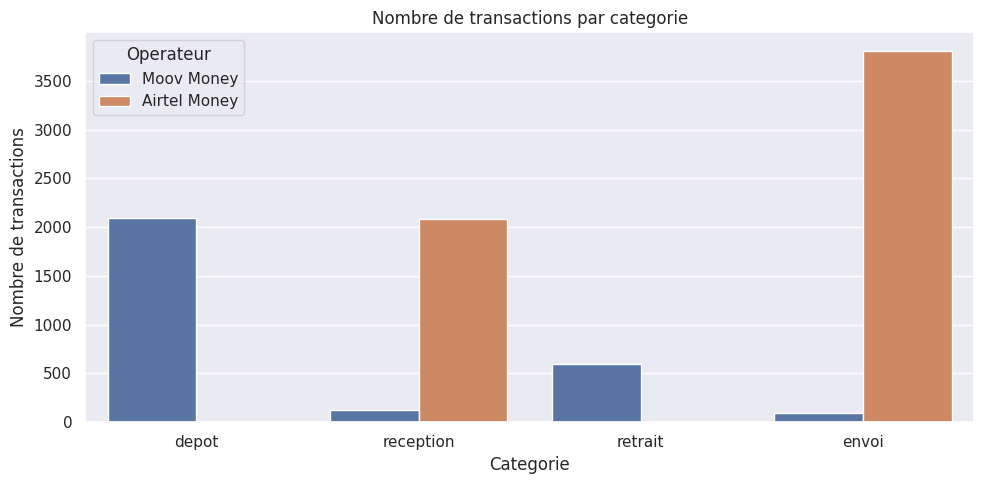

On voit d'un coup d'oeil la spécialisation dans chaque operateur: Airtel Money ne fait quasiment que des envois et réceptions, tndis que Moov Money ne fait que des dépôts et retraits.


In [ ]:
# 1. Creer une figure de taille (10, 5) avec plt.subplots()
fig, ax = plt.subplots(figsize=(10, 5))

# 2. Tracer un diagramme en barres du NOMBRE de transactions par categorie,
#    avec une couleur par operateur
#    Indice : sns.countplot(data=tx, x="categorie", hue="operateur", ax=ax)
sns.countplot(data=tx, x="categorie", hue="operateur", ax=ax)

# 3. Le graphique doit avoir :
#    - un titre qui dit ce qu'on voit
#    - un nom sur l'axe des x et sur l'axe des y (en francais)
#    - une legende lisible
#    (ax.set_title / ax.set_xlabel / ax.set_ylabel / ax.legend)
ax.set_title("Nombre de transactions par categorie")
ax.set_xlabel("Categorie")
ax.set_ylabel("Nombre de transactions")
ax.legend(title="Operateur")

# 4. plt.tight_layout() puis plt.show()
plt.tight_layout()
plt.show()

# 5. En une phrase sous le graphique : que voit-on d'un coup d'oeil
#    qu'on ne voyait pas dans le tableau ?
print("On voit d'un coup d'oeil la spécialisation dans chaque operateur: Airtel Money ne fait quasiment que des envois et réceptions, tndis que Moov Money ne fait que des dépôts et retraits.")

## Question 19 — Graphiques 2 et 3 : quand travaille l'agent ? *(1 pt)*

Deux graphiques pour répondre à la deuxième moitié de la question de l'agent :
**à quel moment ?**

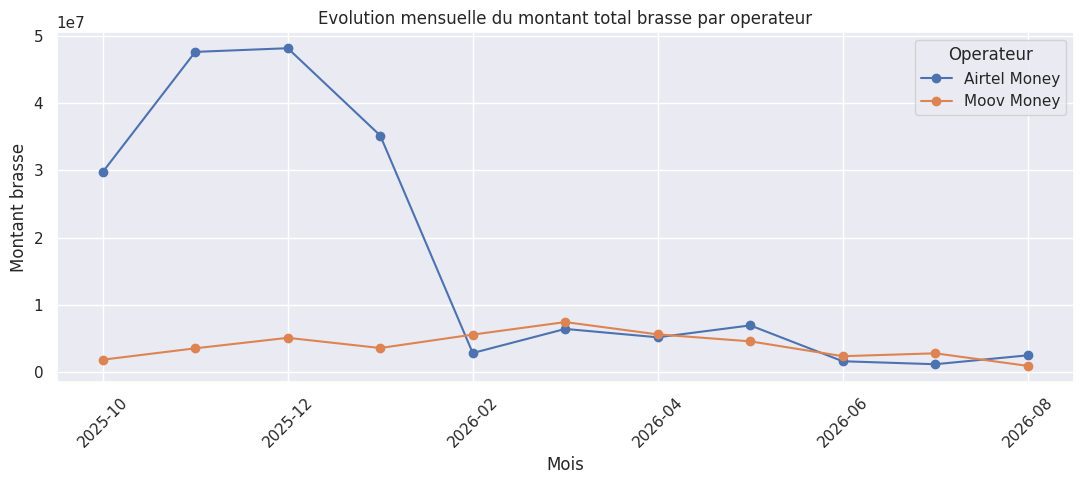

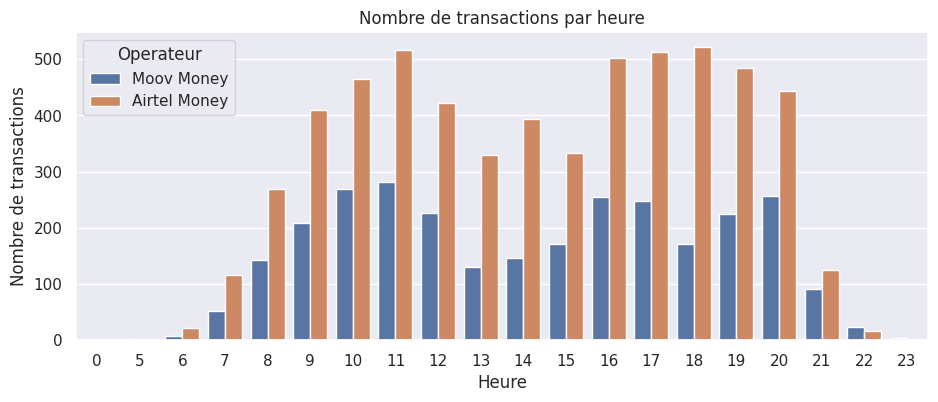


Top 3 heures les plus actives :
heure
11    799
17    760
16    758
Name: count, dtype: int64

Top 3 mois les plus actifs :
mois
2025-12    53226760.62
2025-11    51122352.76
2026-01    38738657.11
dtype: float64
Dans la journée, l'activité est la plus forte vers 11h.
Dans l'année, l'activité la plus forte est atteint en Décembre 2025.


In [ ]:
# --- Graphique 2 : l'evolution mois par mois -------------------------------------
# 1. Tracer mensuel (calcule a la Q17) en courbes, une par operateur,
#    avec des marqueurs ronds : mensuel.plot(marker="o", ax=ax, figsize=(11, 5))
# 2. Titre, axes nommes, legende. Faire pivoter les etiquettes de l'axe x de 45 degres
#    (indice : plt.xticks(rotation=45))
fig, ax = plt.subplots(figsize=(11, 5))
mensuel.plot(marker="o", ax=ax)
ax.set_title("Evolution mensuelle du montant total brasse par operateur")
ax.set_xlabel("Mois")
ax.set_ylabel("Montant brasse")
ax.legend(title="Operateur")
plt.xticks(rotation=45)
# 3. plt.tight_layout() puis plt.show()
plt.tight_layout()
plt.show()

# --- Graphique 3 : l'activite heure par heure ------------------------------------
# 4. Nouvelle figure (11, 4)
# 5. sns.countplot(data=tx, x="heure", hue="operateur", ax=ax)
# 6. Titre, axes nommes, legende, puis affichage
fig, ax = plt.subplots(figsize=(11, 4))
sns.countplot(data=tx, x="heure", hue="operateur", ax=ax)
ax.set_title("Nombre de transactions par heure")
ax.set_xlabel("Heure")
ax.set_ylabel("Nombre de transactions")
ax.legend(title="Operateur")
plt.show()

# 7. Afficher les 3 heures les plus actives et les 3 mois les plus actifs
print("\nTop 3 heures les plus actives :")
print(tx["heure"].value_counts().head(3))

print("\nTop 3 mois les plus actifs :")
print(mensuel.sum(axis=1).sort_values(ascending=False).head(3))


# 8. En deux phrases : quand l'activite est-elle la plus forte, dans la journee
#    et dans l'annee ?
print("Dans la journée, l'activité est la plus forte vers 11h.")
print("Dans l'année, l'activité la plus forte est atteint en Décembre 2025.")

## Question 20 — La synthèse *(1 pt)*

Vous rendez ce notebook à l'agent. Il ne lira pas votre code : il lira **ça**.

Construisez un tableau récapitulatif, puis écrivez vos conclusions dans la cellule de
texte qui suit.

In [ ]:
# 1. Construire un DataFrame resume, une ligne par operateur, avec ces colonnes :
#    - nb_transactions     : le nombre de transactions
#    - montant_total       : la somme des montants
#    - montant_median      : la mediane des montants
#    - montant_max         : le plus gros montant
#    - heure_de_pointe     : l'heure ou il y a le plus de transactions
#    - mois_le_plus_actif  : le mois avec le plus de transactions
#    Indice pour les deux dernieres : .agg(lambda s: s.value_counts().idxmax())
resume = tx.groupby("operateur").agg(
    nb_transactions=("montant", "count"),
    montant_total=("montant", "sum"),
    montant_median=("montant", "median"),
    montant_max=("montant", "max"),
    heure_de_pointe=("heure", lambda s: s.value_counts().idxmax()),
    mois_le_plus_actif=("mois", lambda s: s.value_counts().idxmax())
)

# 2. Afficher resume
print("--- Resume des transactions ---")
print(resume)


# 3. Sauvegarder resume dans un fichier "resume_mobile_money.csv"
#    (indice : .to_csv(...))  -- c'est le livrable qu'on donne a l'agent
resume.to_csv("resume_mobile_money.csv")

# 4. Puis remplir la cellule de texte juste en dessous : 5 conclusions chiffrees
#    et 1 recommandation.

--- Resume des transactions ---
              nb_transactions  montant_total  montant_median  montant_max  \
operateur                                                                   
Airtel Money             5888   1.872984e+08         10000.0     500000.0   
Moov Money               2914   4.342905e+07          5000.0    1200000.0   

              heure_de_pointe mois_le_plus_actif  
operateur                                         
Airtel Money               18            2025-12  
Moov Money                 11            2025-12  


### ✍️  Conclusions


**1.** Volume : Airtel Money domine largement avec 5888 transactions contre 2914 pour Moov Money, soit deux fois plus d'activité.

**2.** Montant : Airtel Money a généré le plus gros montant total avec 187 298 400 FCFA contre 43 429 050 FCFA pour Moov Money.

**3.** Le montant maximum en une seule transaction est de 1 200 000 FCFA pour Moov Money contre 500 000 FCFA pour Airtel Money.

**4.** Horaire : les heures de pointes sont différentes pour chaque opérateur: 18h pour Airtel Money et 11h pour Moov Money.

**5.** Saison : les deux opérateurs ont leur pic d'activité au même moment, en Decembre 2025.

**Ma recommandation à l'agent :** Il faudras que l'agent renforce la liquidité et révoit plus de personnel à 11h pour Moov Money et à 18h pour Airtel Money. Il faut aussi anticiper un besoin de cash important au mois de Décembre pour répondre à la forte demande.